In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

In [ ]:
FILE_TEXT = "emails (2).csv"
FILE_NUMERIC = "emails.csv"

df_text = pd.read_csv(FILE_TEXT, on_bad_lines='skip', encoding='latin-1')
df_num = pd.read_csv(FILE_NUMERIC, on_bad_lines='skip', encoding='latin-1')

TEXT_COLUMN = "text"
LABEL_COLUMN = "spam"

Data cleaning


In [ ]:
min_len = min(len(df_text), len(df_num))

df_text = df_text.head(min_len).dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)
df_num = df_num.head(min_len).reset_index(drop=True)

y = df_text[LABEL_COLUMN].astype(int).values

Load Bert

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

bert_model.to(device)
bert_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

Generate Embeddings

In [ ]:
def get_embeddings(texts):

    embeddings = []

    for i in range(0, len(texts), 32):

        batch = texts[i:i+32]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        with torch.no_grad():
            output = bert_model(input_ids, attention_mask=attention_mask)

        cls = output.last_hidden_state[:,0,:].cpu().numpy()
        embeddings.extend(cls)

    return np.array(embeddings)

Create Features

In [ ]:
X_text = get_embeddings(df_text[TEXT_COLUMN].astype(str).tolist())

df_num = df_num.drop(columns=['Email No.', 'Prediction'], errors='ignore')
X_num = df_num.apply(pd.to_numeric, errors='coerce').fillna(0).values

X = np.concatenate([X_text, X_num], axis=1)

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Hybrid MLP Model

In [ ]:
class HybridMLP(nn.Module):

    def __init__(self, input_dim, hidden1=512, hidden2=128, dropout=0.3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

Training

In [ ]:
model = HybridMLP(X.shape[1]).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_tensor = torch.tensor(X_train).float()
label_tensor = torch.tensor(y_train).float().unsqueeze(1)

dataset = TensorDataset(train_tensor, label_tensor)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

for epoch in range(5):

    model.train()
    loss_total = 0

    for xb, yb in loader:

        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(pred, yb)

        loss.backward()

        optimizer.step()

        loss_total += loss.item()

    print("Epoch",epoch+1,"Loss:",loss_total/len(loader))

Epoch 1 Loss: 0.47363640684418695
Epoch 2 Loss: 0.24876647465592647
Epoch 3 Loss: 0.13829407484259845
Epoch 4 Loss: 0.10416726213718071
Epoch 5 Loss: 0.07024119270949275


Evaluation

In [ ]:
model.eval()

with torch.no_grad():

    preds = model(torch.tensor(X_test).float().to(device)).cpu().numpy()

preds = (preds > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test,preds))
print("F1:", f1_score(y_test,preds))
print("ROC:", roc_auc_score(y_test,preds))
print(classification_report(y_test,preds))

Accuracy: 0.9603864734299516
F1: 0.9216061185468452
ROC: 0.934524780110688
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       761
           1       0.97      0.88      0.92       274

    accuracy                           0.96      1035
   macro avg       0.96      0.93      0.95      1035
weighted avg       0.96      0.96      0.96      1035



HyperParameter Tuning

In [ ]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, f1_score

params = {
    "hidden1":[256,512],
    "hidden2":[64,128],
    "dropout":[0.2,0.3,0.5]
}

results = []

for p in ParameterGrid(params):

    model = HybridMLP(
        X.shape[1],
        p["hidden1"],
        p["hidden2"],
        p["dropout"]
    ).to(device)

    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # training tensors
    X_train_tensor = torch.tensor(X_train).float().to(device)
    y_train_tensor = torch.tensor(y_train).float().unsqueeze(1).to(device)

    # quick training (3 epochs is enough for tuning)
    for epoch in range(3):

        model.train()

        optimizer.zero_grad()

        outputs = model(X_train_tensor)

        loss = criterion(outputs, y_train_tensor)

        loss.backward()
        optimizer.step()

    # evaluation
    model.eval()

    with torch.no_grad():
        preds = model(torch.tensor(X_test).float().to(device)).cpu().numpy()

    preds = (preds > 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({
        "hidden1": p["hidden1"],
        "hidden2": p["hidden2"],
        "dropout": p["dropout"],
        "accuracy": acc,
        "f1": f1
    })

df_results = pd.DataFrame(results)
print(df_results.sort_values("accuracy", ascending=False))

    hidden1  hidden2  dropout  accuracy        f1
1       256      128      0.2  0.735266  0.000000
2       512       64      0.2  0.735266  0.000000
3       512      128      0.2  0.735266  0.000000
4       256       64      0.3  0.735266  0.000000
8       256       64      0.5  0.735266  0.000000
5       256      128      0.3  0.735266  0.000000
6       512       64      0.3  0.735266  0.000000
7       512      128      0.3  0.735266  0.000000
10      512       64      0.5  0.735266  0.000000
9       256      128      0.5  0.735266  0.000000
11      512      128      0.5  0.735266  0.000000
0       256       64      0.2  0.615459  0.174274


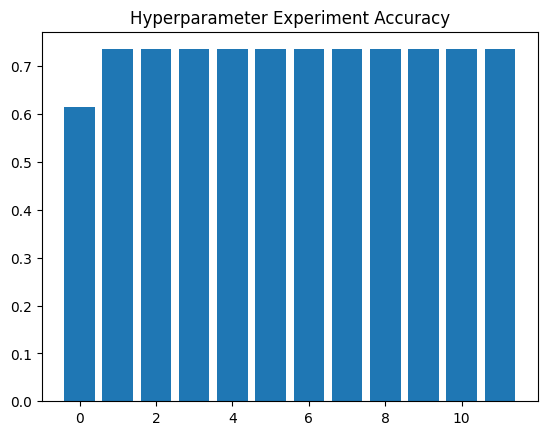

In [ ]:
import matplotlib.pyplot as plt

plt.bar(range(len(df_results)), df_results["accuracy"])
plt.title("Hyperparameter Experiment Accuracy")
plt.show()

Compare With Traditional ML Model

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test,pred))

SVM Accuracy: 0.7371980676328502


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline = scaling + SVM
svm_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # important for sparse data
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced'))
])

# Train
svm_model.fit(X_train, y_train)

# Predict
pred = svm_model.predict(X_test)
prob = svm_model.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC:", roc_auc_score(y_test, prob))
print(classification_report(y_test, pred))

Accuracy: 0.9642512077294686
F1: 0.9300567107750473
ROC: 0.9957460889916265
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       761
           1       0.96      0.90      0.93       274

    accuracy                           0.96      1035
   macro avg       0.96      0.94      0.95      1035
weighted avg       0.96      0.96      0.96      1035



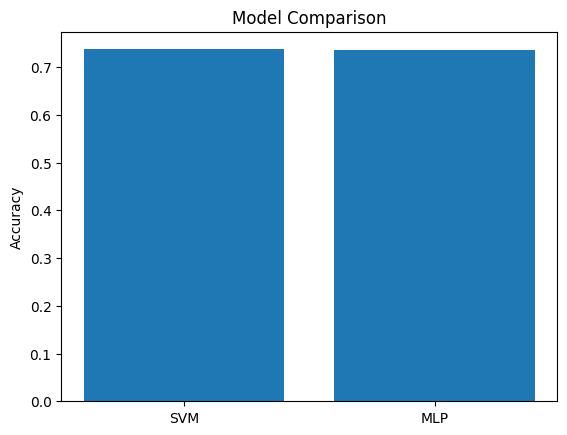

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["SVM","MLP"], [accuracy_score(y_test,pred), accuracy_score(y_test,preds)])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
print("Spam ratio:", y.mean())

Spam ratio: 0.26450116009280744


Dataset is imbalanced.

Hybrid MlP Model updated

In [ ]:
class HybridMLP(nn.Module):

    def __init__(self, input_dim, hidden1=512, hidden2=128, dropout=0.3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.model(x)

HYBRID MLP TRAINING

In [ ]:
model = HybridMLP(X.shape[1]).to(device)

pos_weight = torch.tensor([(len(y_train)-y_train.sum())/y_train.sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_tensor = torch.tensor(X_train).float()
label_tensor = torch.tensor(y_train).float().unsqueeze(1)

dataset = TensorDataset(train_tensor, label_tensor)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

for epoch in range(5):

    model.train()
    loss_total = 0

    for xb, yb in loader:

        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(pred, yb)

        loss.backward()

        optimizer.step()

        loss_total += loss.item()

    print("Epoch",epoch+1,"Loss:",loss_total/len(loader))

Epoch 1 Loss: 0.8354996781091433
Epoch 2 Loss: 0.3750427271523531
Epoch 3 Loss: 0.22917723498202888
Epoch 4 Loss: 0.16967317483902092
Epoch 5 Loss: 0.1256580090376775


Evaluation

In [ ]:
test_tensor = torch.tensor(X_test).float()
test_labels = torch.tensor(y_test).float().unsqueeze(1)

test_dataset = TensorDataset(test_tensor, test_labels)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
model.eval()

preds = []
labels = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        outputs = model(xb)

        probs = torch.sigmoid(outputs)

        preds.extend((probs.cpu().numpy() > 0.5).astype(int).flatten())
        labels.extend(yb.numpy())

print("Accuracy:", accuracy_score(labels, preds))
print("F1:", f1_score(labels, preds))
print("ROC:", roc_auc_score(labels, preds))
print(classification_report(labels, preds))

Accuracy: 0.9690821256038648
F1: 0.9440559440559441
ROC: 0.9743038836720797
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98       761
         1.0       0.91      0.99      0.94       274

    accuracy                           0.97      1035
   macro avg       0.95      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035



In [ ]:
print(pd.Series(y_train).value_counts())

0    3043
1    1094
Name: count, dtype: int64


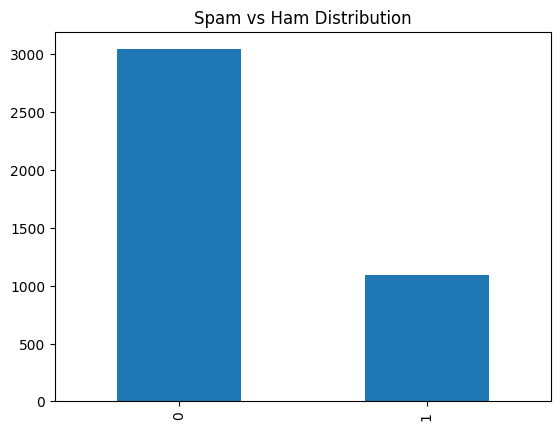

In [ ]:
import matplotlib.pyplot as plt

pd.Series(y_train).value_counts().plot(kind="bar")
plt.title("Spam vs Ham Distribution")
plt.show()

logistic regression


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score

model = LogisticRegression(class_weight='balanced', max_iter=2000)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))

print(classification_report(y_test, pred))

Accuracy: 0.9710144927536232
F1: 0.946236559139785
ROC-AUC: 0.9908879020113757
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       761
           1       0.93      0.96      0.95       274

    accuracy                           0.97      1035
   macro avg       0.96      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035



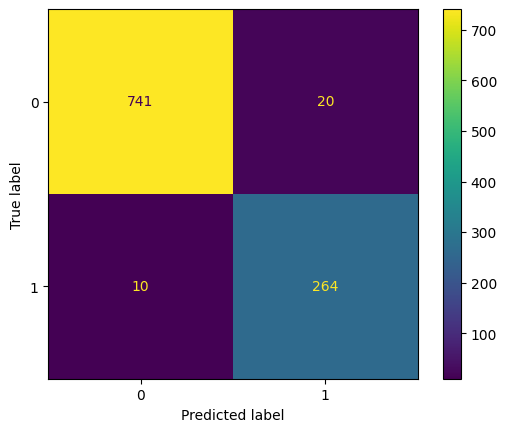

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, pred)

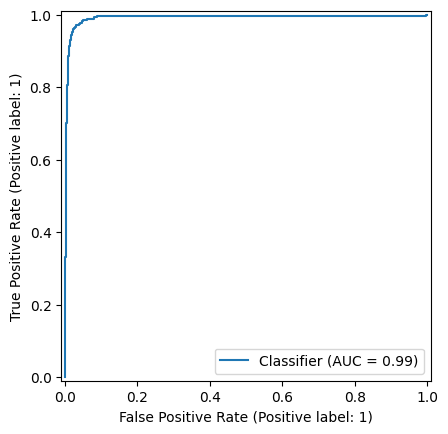

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, prob)


In [ ]:
import pandas as pd

df = pd.read_csv("/content/emails (2).csv")

df = df.rename(columns={"spam":"label"})

In [ ]:
print(df.columns)

Index(['text', 'label'], dtype='object')


In [ ]:
print(df.head())
print(df.columns)

                                                text  label
0  Subject: naturally irresistible your corporate...      1
1  Subject: the stock trading gunslinger  fanny i...      1
2  Subject: unbelievable new homes made easy  im ...      1
3  Subject: 4 color printing special  request add...      1
4  Subject: do not have money , get software cds ...      1
Index(['text', 'label'], dtype='object')


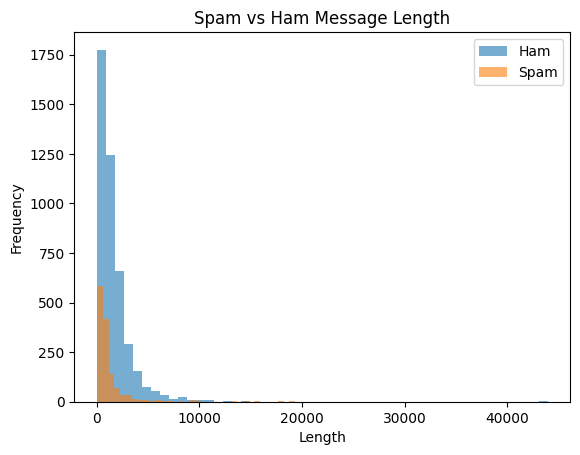

In [ ]:
import matplotlib.pyplot as plt

df['msg_length'] = df['text'].astype(str).apply(len)

plt.hist(df[df['label']==0]['msg_length'], bins=50, alpha=0.6, label="Ham")
plt.hist(df[df['label']==1]['msg_length'], bins=50, alpha=0.6, label="Spam")

plt.legend()
plt.title("Spam vs Ham Message Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

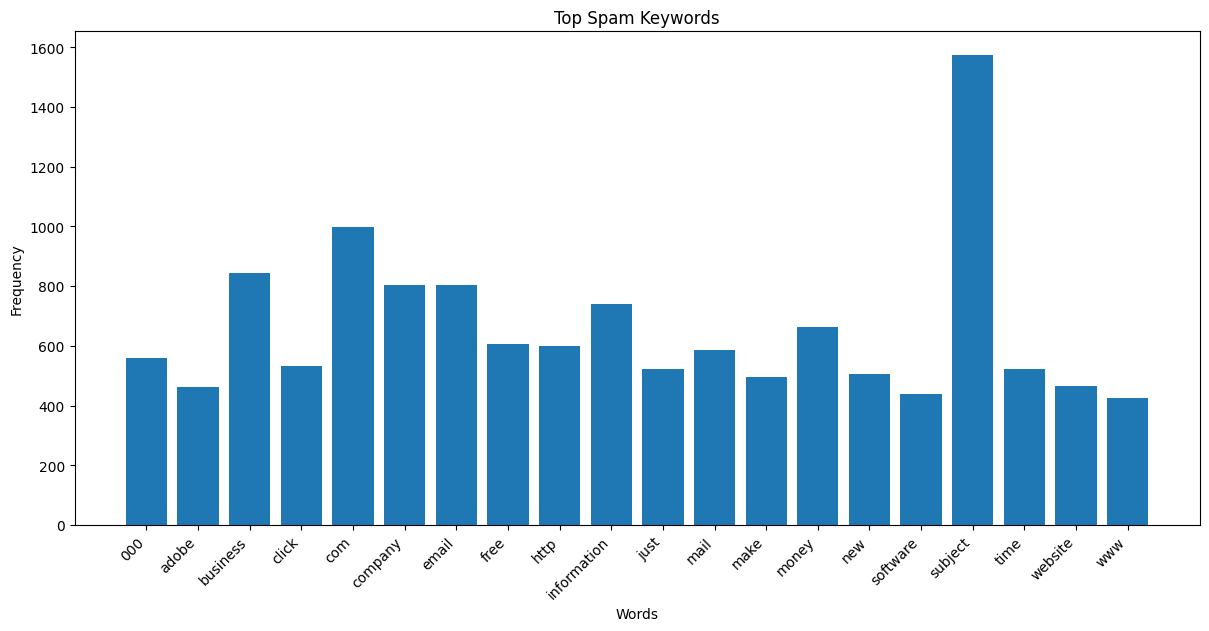

In [ ]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

spam_text = df[df['label']==1]['text']

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(spam_text)

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

plt.figure(figsize=(12,6))   # makes it spacious

plt.bar(words, counts)

plt.xticks(rotation=45, ha='right')  # cleaner labels
plt.tight_layout()  # prevents cutting labels

plt.title("Top Spam Keywords")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

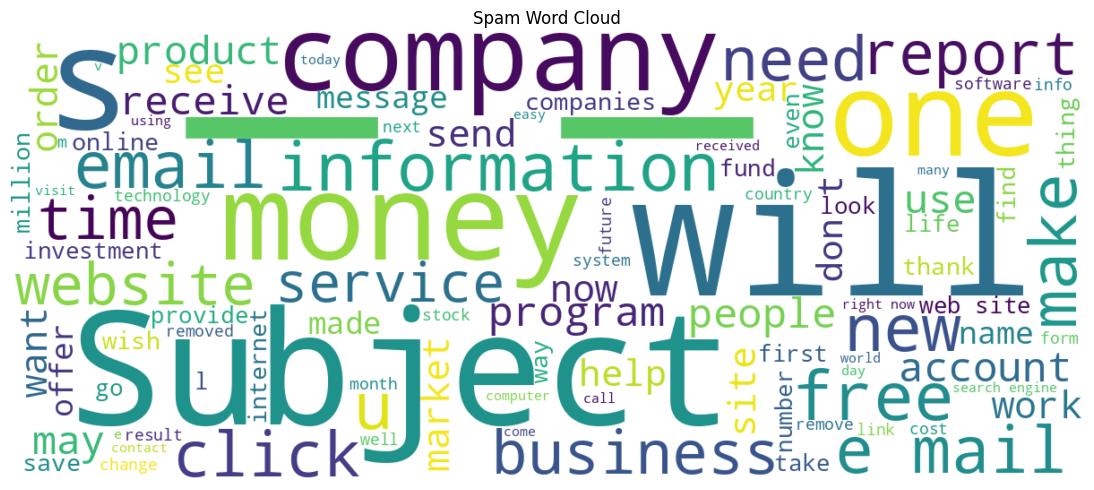

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all spam text
spam_text = " ".join(df[df['label']==1]['text'])

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=500,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(spam_text)

# Plot
plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Word Cloud")
plt.tight_layout()

# Save for Overleaf
plt.savefig("spam_wordcloud.png", dpi=300)

plt.show()

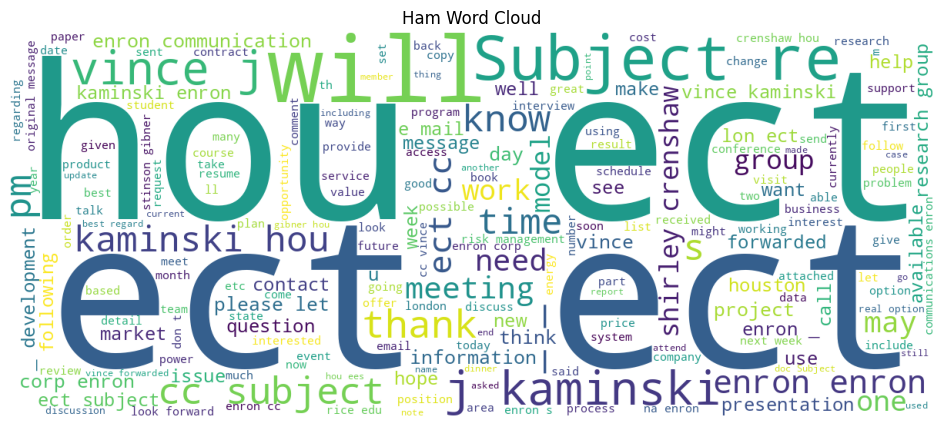

In [ ]:
ham_text = " ".join(df[df['label']==0]['text'])

wc = WordCloud(width=1200, height=500, background_color='white').generate(ham_text)

plt.figure(figsize=(12,5))
plt.imshow(wc)
plt.axis('off')
plt.title("Ham Word Cloud")

plt.savefig("ham_wordcloud.png", dpi=300)
plt.show()

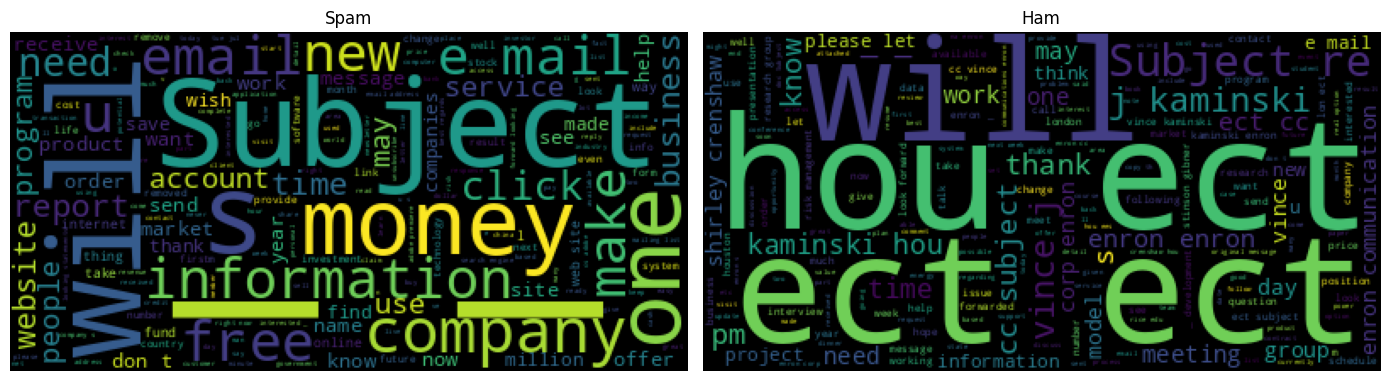

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(14,5))

axs[0].imshow(WordCloud().generate(spam_text))
axs[0].set_title("Spam")
axs[0].axis('off')

axs[1].imshow(WordCloud().generate(ham_text))
axs[1].set_title("Ham")
axs[1].axis('off')

plt.tight_layout()
plt.savefig("comparison_wordcloud.png", dpi=300)
plt.show()

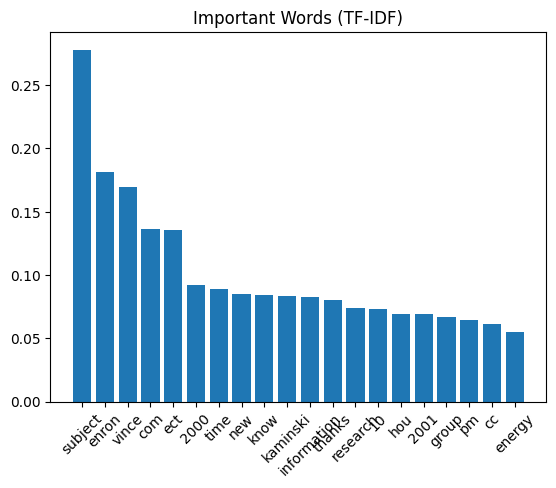

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=20)
X = tfidf.fit_transform(df['text'])

scores = X.toarray().mean(axis=0)
words = tfidf.get_feature_names_out()

import numpy as np
idx = np.argsort(scores)[::-1]

plt.bar(words[idx], scores[idx])
plt.xticks(rotation=45)
plt.title("Important Words (TF-IDF)")
plt.show()

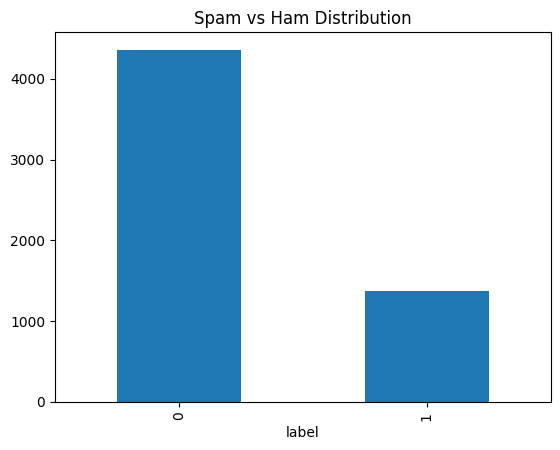

In [ ]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.show()